In [1]:
pip install sentence-transformers seaborn matplotlib scikit-learn

   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
    --------------------------------------- 0.3/10.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.7 MB 927.7 kB/s eta 0:00:11
   -- ------------------------------------- 0.8/10.7 MB 876.5 kB/s eta 0:00:12
   --- ------------------------------------ 1.0/10.7 MB 992.3 kB/s eta 0:00:10
   ---- ----------------------------------- 1.3/10.7 MB 1.0 MB/s eta 0:00:10
   ----- ---------------------------------- 1.6/10.7 MB 1.0 MB/s eta 0:00:09
   ------ --------------------------------- 1.8/10.7 MB 1.1 MB/s eta 0:00:09
   -------- ------------------------------- 2.4/10.7 MB 1.2 MB/s eta 0:00:07
   -------- ------------------------------- 2.4/10.7 MB 1.2 MB/s eta 0:00:07
   ---------- ----------------------------- 2.9/10.7 MB 1.2 MB/s eta 0:00:07
   ------------ -----

In [2]:
sentences = [
    # Cricket (4)
    "The batsman scored a century in the match",
    "The bowler delivered a fast yorker",
    "The team won the cricket tournament",
    "The fielder took a stunning catch",

    # Cooking (3)
    "She cooked a delicious pasta for dinner",
    "The chef prepared a spicy curry",
    "Baking a cake requires precise measurements",

    # Cybersecurity (3)
    "Strong passwords help protect your accounts",
    "Hackers use phishing attacks to steal data",
    "Installing antivirus software improves security"
]

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\Predun\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Predun\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [4]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

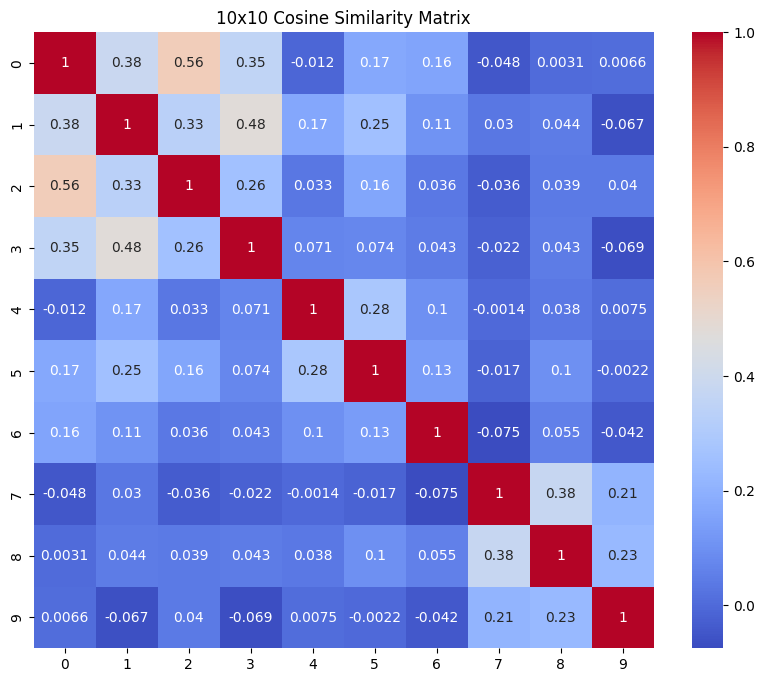

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')

plt.title("10x10 Cosine Similarity Matrix")
plt.show()

In [6]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

In [7]:
similarities = cosine_similarity(query_embedding, embeddings)[0]

In [8]:
import numpy as np

top_indices = np.argsort(similarities)[-2:][::-1]

for i in top_indices:
    print("Sentence:", sentences[i])
    print("Similarity Score:", similarities[i])
    print()

Sentence: The batsman scored a century in the match
Similarity Score: 0.56821966

Sentence: The bowler delivered a fast yorker
Similarity Score: 0.5413827

